# Kendall-tau inflation — candidate corrections

Pool-level Kendall (current) is grossly inflated: GIF ~9.2, ~52% of the genome at
p<0.05 (355 pools nested in only ~31 independent climate sites). Candidates:

| method | what it does | trade-off |
|---|---|---|
| **pool_raw** | per-SNP Kendall across 355 pools (CURRENT) | GIF ~9.2 — indefensible |
| **pool_gc** | pool_raw + genomic-control (divide chi2 by lambda) | keeps 355-pool resolution -> **tall peaks**, GIF->1; = what LFMM does internally |
| **site_gc** | site-collapsed Kendall (31 sites) + GC | honest unit, but 31 obs -> coarse/modest peaks |
| **msr** | site rank + structure-preserving MSR null | GIF ~1.3 but p floored at 1e-4 (10k perms) -> flat-ceiling Manhattan (shown for contrast; NOT recommended for a GEA figure or WZA) |

Genomic control (GC) is the standard fix for a uniformly-inflated test: estimate
lambda = median(chi2_obs)/median(chi2_null), divide every chi2 by it, recompute p.
Continuous p (no permutation floor), GIF->1 by construction, and — on the pool
statistic — retains resolution so peaks rise above the line, exactly like LFMM.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

CLQ = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/r2_gea_nonsnp/phase1_replication/results/clq90"
SITE = f"{CLQ}/kendall_fix_test/site_collapsed"
MSRDIR = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/archive/gea_newpanel_snp_nonsnp_fork_retired/results/msr_kendall"
CLASSES = ["snp", "nonsnp"]
METHODS = ["pool_raw", "pool_gc", "site_gc", "msr"]
METHOD_LABEL = {"pool_raw": "pool-level RAW (current, 355 pools)",
                "pool_gc": "pool-level + genomic control",
                "site_gc": "site-collapsed (31) + genomic control",
                "msr": "MSR structure-null (floored 1e-4)"}
CHROMS = [f"Chr{i}" for i in range(1, 6)]
Q_FLOOR = 1e-16
COLORS = {"pool_raw": "#7f7f7f", "pool_gc": "#1f77b4", "site_gc": "#2ca02c", "msr": "#d62728"}
NULLMED = chi2.ppf(0.5, 1)

def gif(p):
    p = np.asarray(p, float); p = p[np.isfinite(p) & (p > 0)]
    return float(np.median(chi2.isf(p, 1)) / NULLMED)

def gc_calibrate(p, lam):
    p = np.asarray(p, float)
    x2 = chi2.isf(np.clip(p, 1e-300, 1), 1)
    return chi2.sf(x2 / lam, 1)

def _load_kendall(path):
    d = pd.read_csv(path, usecols=["chrom", "pos", "MAF", "pval"])
    d = d[(d.MAF >= 0.05) & d.chrom.astype(str).isin(CHROMS) & d.pval.notna() & (d.pval > 0)].copy()
    d["chrom"] = d["chrom"].astype(str)
    return d

# raw sources
_POOL = {c: _load_kendall(f"{CLQ}/wza_in/kendall_{c}_gen9_bio1.csv") for c in CLASSES}
_SITE = {c: _load_kendall(f"{SITE}/kendall_site_{c}_gen9_bio1.csv") for c in CLASSES}

def load(method, cls):
    if method == "pool_raw":
        return _POOL[cls][["chrom", "pos", "pval"]].copy()
    if method == "pool_gc":
        d = _POOL[cls].copy(); d["pval"] = gc_calibrate(d["pval"].to_numpy(), gif(d["pval"])); return d[["chrom","pos","pval"]]
    if method == "site_gc":
        d = _SITE[cls].copy(); d["pval"] = gc_calibrate(d["pval"].to_numpy(), gif(d["pval"])); return d[["chrom","pos","pval"]]
    if method == "msr":
        z = np.load(f"{MSRDIR}/msr_arrays_{cls}_bio1.npz")
        d = pd.DataFrame({"chrom": z["chrom"].astype(str), "pos": z["pos"].astype(np.int64), "pval": z["p_msr"]})
        return d[d.chrom.isin(CHROMS)].copy()

def bh_count_crit(p, q=0.05):
    v = np.sort(np.asarray(p, float)); m = len(v)
    ok = v <= q * np.arange(1, m + 1) / m
    k = int(np.flatnonzero(ok).max() + 1) if ok.any() else 0
    return k, (q * k / m if k else np.nan)

# shared genome x-axis
allpos = pd.concat([_POOL[c][["chrom", "pos"]] for c in CLASSES])
chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
GAP = 5e6
offset, off = {}, 0.0
for c in CHROMS:
    offset[c] = off; off += chrom_max[c] + GAP
ticks = [offset[c] + chrom_max[c] / 2 for c in CHROMS]
chrom_col = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}

print("GIF check:", {(m, c): round(gif(load(m, c)["pval"]), 2) for m in METHODS for c in CLASSES})

GIF check: {('pool_raw', 'snp'): 9.25, ('pool_raw', 'nonsnp'): 9.18, ('pool_gc', 'snp'): 1.0, ('pool_gc', 'nonsnp'): 1.0, ('site_gc', 'snp'): 1.0, ('site_gc', 'nonsnp'): 1.0, ('msr', 'snp'): 1.3, ('msr', 'nonsnp'): 1.34}


## QQ plot (raw per-record p, calibration)

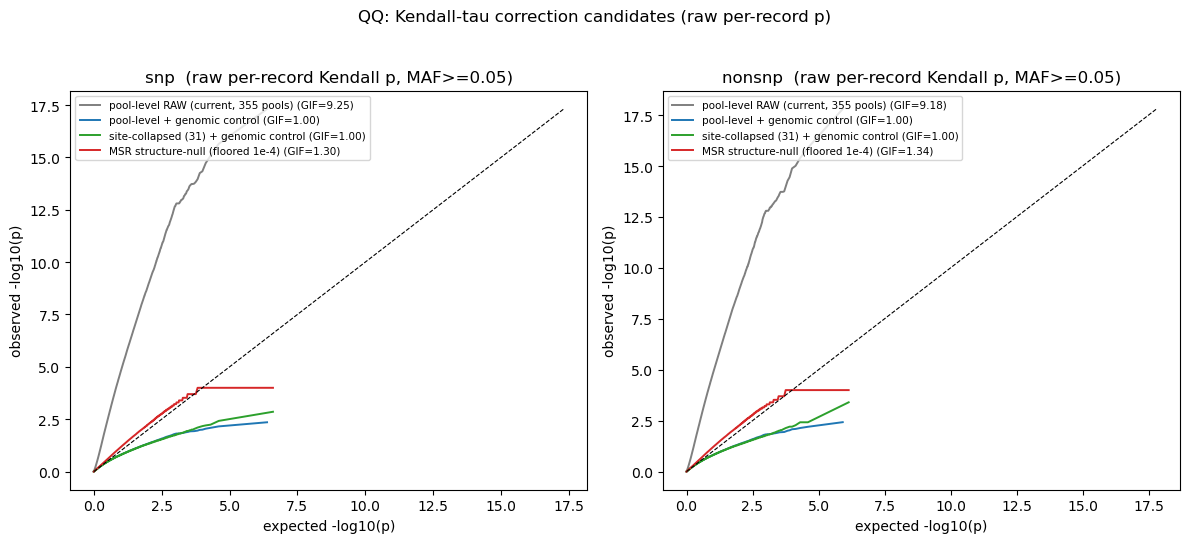

In [2]:
def qq_points(p, maxn=40000):
    p = np.sort(np.asarray(p, float)); p = p[np.isfinite(p) & (p > 0)]
    n = len(p)
    exp = -np.log10((np.arange(1, n + 1) - 0.5) / n)
    obs = -np.log10(np.clip(p, 1e-320, 1))
    if n > maxn:
        idx = np.unique(np.r_[np.linspace(0, n - 1, maxn).astype(int), np.arange(n - 300, n)])
        exp, obs = exp[idx], obs[idx]
    return exp, obs

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, cls in zip(axes, CLASSES):
    mx = 0
    for method in METHODS:
        p = load(method, cls)["pval"].to_numpy()
        ex, ob = qq_points(p)
        ax.plot(ex, ob, color=COLORS[method], lw=1.4,
                label=f"{METHOD_LABEL[method]} (GIF={gif(p):.2f})")
        mx = max(mx, ex.max(), ob.max())
    ax.plot([0, mx], [0, mx], "k--", lw=0.8)
    ax.set_xlabel("expected -log10(p)"); ax.set_ylabel("observed -log10(p)")
    ax.set_title(f"{cls}  (raw per-record Kendall p, MAF>=0.05)")
    ax.legend(fontsize=7.5, loc="upper left")
fig.suptitle("QQ: Kendall-tau correction candidates (raw per-record p)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(f"{CLQ}/kendall_fix_test/qq_kendall_fix_compare.png", dpi=140, bbox_inches="tight")
plt.show()

## Raw per-record Manhattan (pre-WZA)

Bonferroni (red dashed) + BH q<0.05 (orange dotted) per-record lines. Compare peak
height and how the tail behaves — pool_gc should keep tall, resolved peaks;
site_gc modest; msr slammed flat against its 1e-4 ceiling.

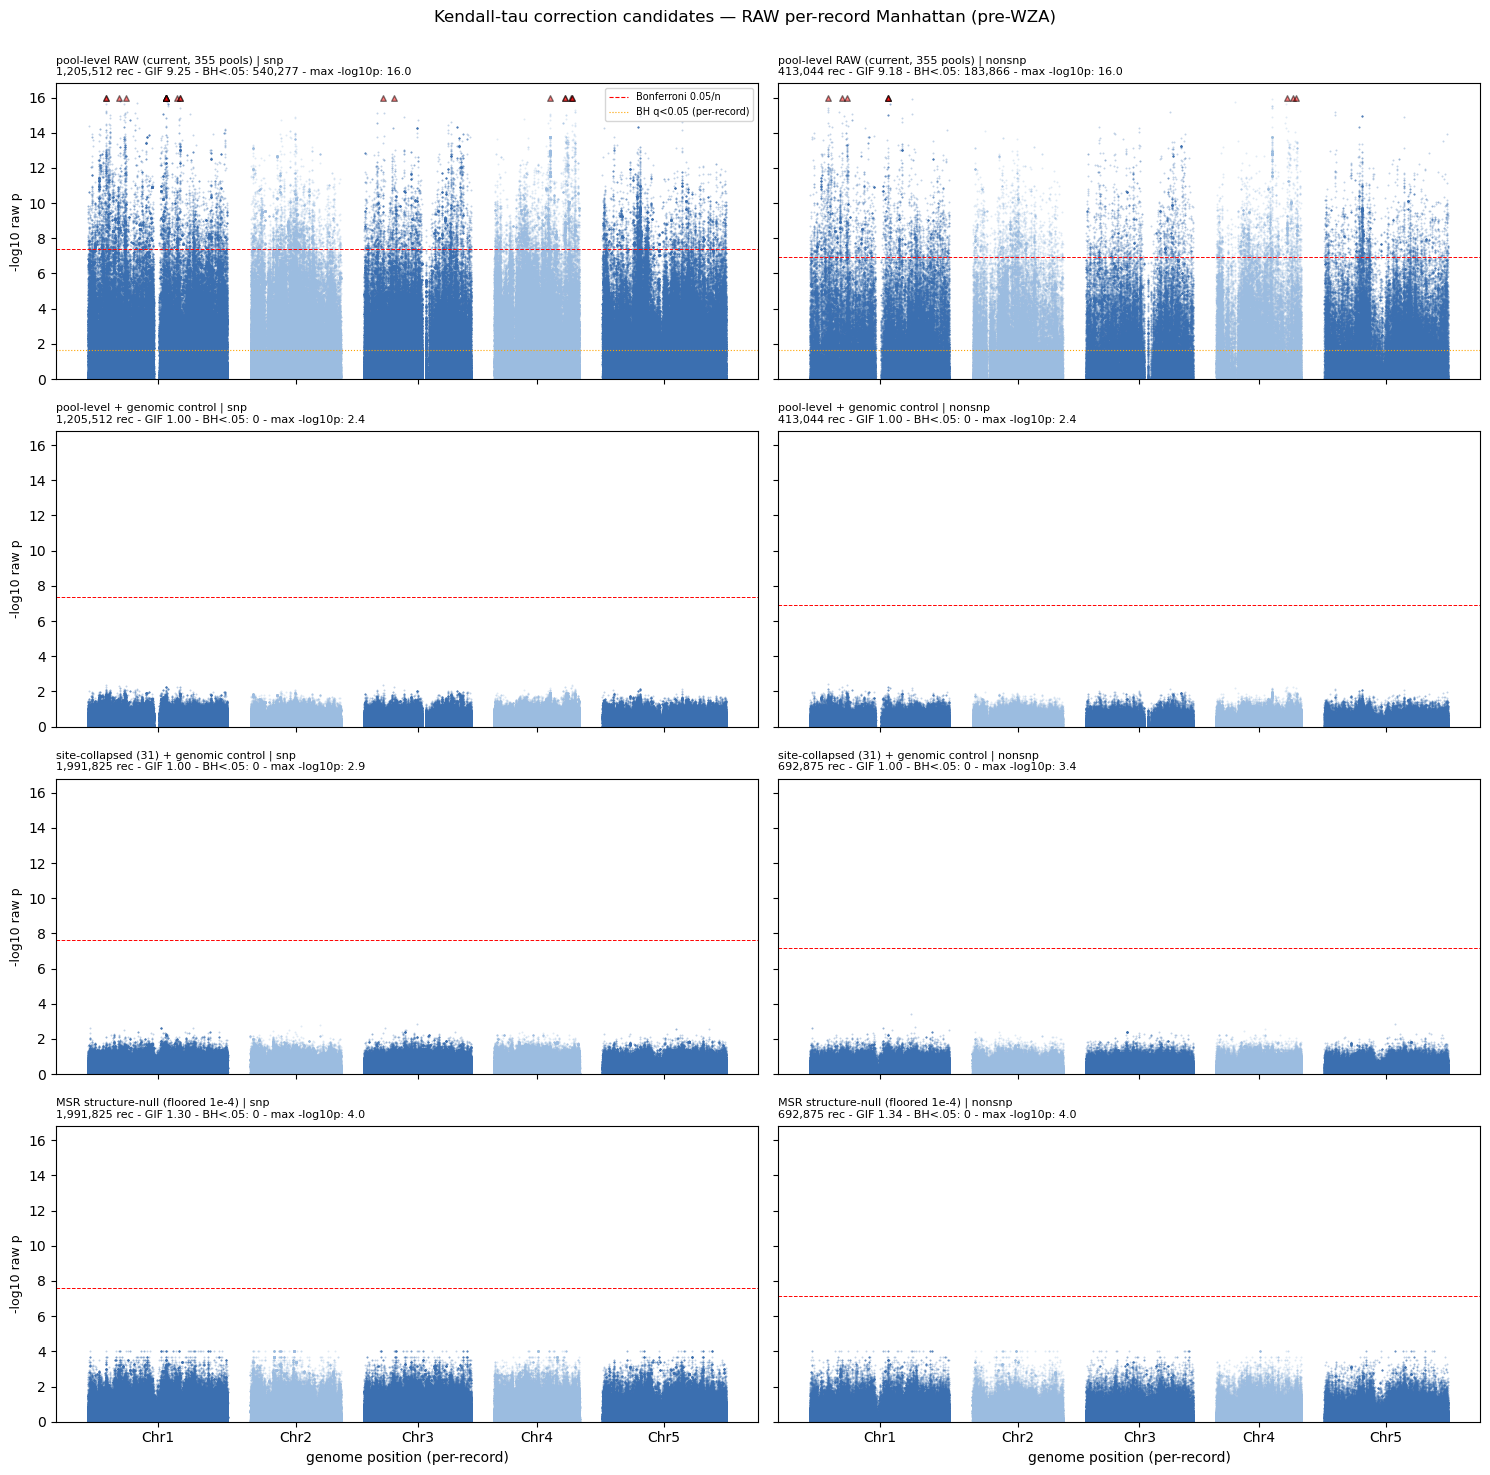

In [3]:
RAW_YMAX = -np.log10(Q_FLOOR)

fig, axes = plt.subplots(len(METHODS), len(CLASSES), figsize=(15, 15), sharex=True, sharey=True)
for r, method in enumerate(METHODS):
    for cc, cls in enumerate(CLASSES):
        ax = axes[r, cc]
        d = load(method, cls).copy()
        d["x"] = d["pos"] + d["chrom"].map(offset)
        d["mlogp"] = -np.log10(d["pval"].clip(lower=Q_FLOOR))
        n = len(d)
        y = d["mlogp"].clip(upper=RAW_YMAX)
        ofs = d["pval"] < Q_FLOOR
        for c in CHROMS:
            m = (d["chrom"] == c) & ~ofs
            ax.scatter(d["x"][m], y[m], s=2, c=chrom_col[c], alpha=.3, linewidths=0, rasterized=True)
        if ofs.any():
            ax.scatter(d["x"][ofs], np.full(int(ofs.sum()), RAW_YMAX), marker="^", s=16,
                       color="red", edgecolor="k", zorder=6, alpha=.5)
        bonf = 0.05 / n
        ax.axhline(-np.log10(bonf), color="red", lw=0.7, ls="--")
        nbh, crit = bh_count_crit(d["pval"].to_numpy())
        if nbh:
            ax.axhline(-np.log10(crit), color="orange", lw=0.8, ls=":")
        ax.set_title(f"{METHOD_LABEL[method]} | {cls}\n{n:,} rec - GIF {gif(d['pval']):.2f} "
                     f"- BH<.05: {nbh:,} - max -log10p: {d['mlogp'].max():.1f}", fontsize=8, loc="left")
        if cc == 0:
            ax.set_ylabel("-log10 raw p", fontsize=9)
        ax.set_ylim(0, RAW_YMAX + 0.8)
for ax in axes[-1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (per-record)")
axes[0, 0].plot([], [], color="red", ls="--", lw=0.8, label="Bonferroni 0.05/n")
axes[0, 0].plot([], [], color="orange", ls=":", lw=0.8, label="BH q<0.05 (per-record)")
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("Kendall-tau correction candidates — RAW per-record Manhattan (pre-WZA)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(f"{CLQ}/kendall_fix_test/manhattan_raw_kendall_fix_compare.png", dpi=130, bbox_inches="tight")
plt.show()

## Summary + CAM5 spot-check

In [4]:
rows = []
for method in METHODS:
    for cls in CLASSES:
        d = load(method, cls); p = d["pval"].to_numpy()
        nbh, _ = bh_count_crit(p)
        rows.append(dict(method=method, cls=cls, n=len(d), gif=round(gif(p), 2),
                         frac_p05=round(float((p < 0.05).mean()), 3),
                         min_p=float(np.nanmin(p)), max_mlogp=round(float(-np.log10(np.nanmin(p))), 1),
                         n_bh=nbh))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary

  method    cls       n  gif  frac_p05        min_p  max_mlogp   n_bh
pool_raw    snp 1205512 9.25     0.520 4.870699e-18       17.3 540277
pool_raw nonsnp  413044 9.18     0.519 1.583900e-18       17.8 183866
 pool_gc    snp 1205512 1.00     0.012 4.419534e-03        2.4      0
 pool_gc nonsnp  413044 1.00     0.013 3.749461e-03        2.4      0
 site_gc    snp 1991825 1.00     0.011 1.392202e-03        2.9      0
 site_gc nonsnp  692875 1.00     0.011 3.970391e-04        3.4      0
     msr    snp 1991825 1.30     0.078 9.999000e-05        4.0      0
     msr nonsnp  692875 1.34     0.081 9.999000e-05        4.0      0


,method,cls,n,gif,frac_p05,min_p,max_mlogp,n_bh
0,pool_raw,snp,1205512,9.25,0.520,4.870699e-18,17.3,540277
1,pool_raw,nonsnp,413044,9.18,0.519,1.583900e-18,17.8,183866
2,pool_gc,snp,1205512,1.00,0.012,4.419534e-03,2.4,0
3,pool_gc,nonsnp,413044,1.00,0.013,3.749461e-03,2.4,0
4,site_gc,snp,1991825,1.00,0.011,1.392202e-03,2.9,0
5,site_gc,nonsnp,692875,1.00,0.011,3.970391e-04,3.4,0
6,msr,snp,1991825,1.30,0.078,9.999000e-05,4.0,0
7,msr,nonsnp,692875,1.34,0.081,9.999000e-05,4.0,0
